In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import contextily as ctx
import matplotlib.pyplot as plt
import xyzservices as xyz
import coiled
#import hvplot.xarray
#import cartopy.crs as ccrs
from global_snowmelt_runoff_onset.config import Config, Tile
import easysnowdata
import rioxarray as rxr

In [2]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-05-01 05:50 UTC (223.7 hours)


----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
seasonal_snow_mask_reproject_method = rasterio
-------------------

In [3]:
global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
global_ds

<xarray.Dataset> Size: 14TB
Dimensions:                     (latitude: 195970, longitude: 499998,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [13]:
dischma_basin_gdf = gpd.read_file("zip:geometries/bareerah_alps/shp.zip!shp/lidar_coverage_area.shp")
dischma_basin_gdf

,id,name,geometry
0,1,LiDAR_coverage,"POLYGON ((779200 190000, 785300 190000, 785300..."


In [15]:
dischma_basin_ds = global_ds.rio.clip_box(*dischma_basin_gdf.total_bounds, crs=dischma_basin_gdf.crs)
dischma_basin_ds

<xarray.Dataset> Size: 10MB
Dimensions:                     (latitude: 232, longitude: 302, water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2kB 46.84 46.84 ... 46.67
  * longitude                   (longitude) float64 2kB 9.771 9.772 ... 9.988
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
    spatial_ref                 int64 8B 0
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 3MB dask.array<chunksize=(1, 232, 302), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 561kB dask.array<chunksize=(232, 302), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 280kB dask.array<chunksize=(232, 302), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 6MB dask.array<chunksize=(1, 232, 302), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 561kB dask.array<chunksize=(232, 302), meta=np.ndarray>
Attributes:
    processed_tiles:  []

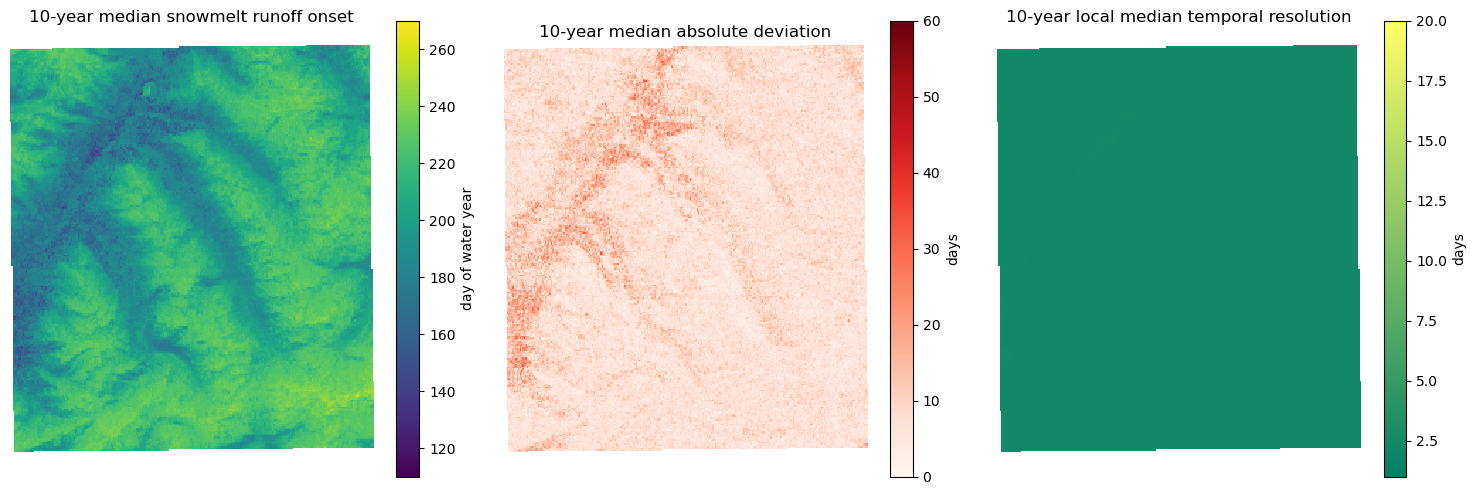

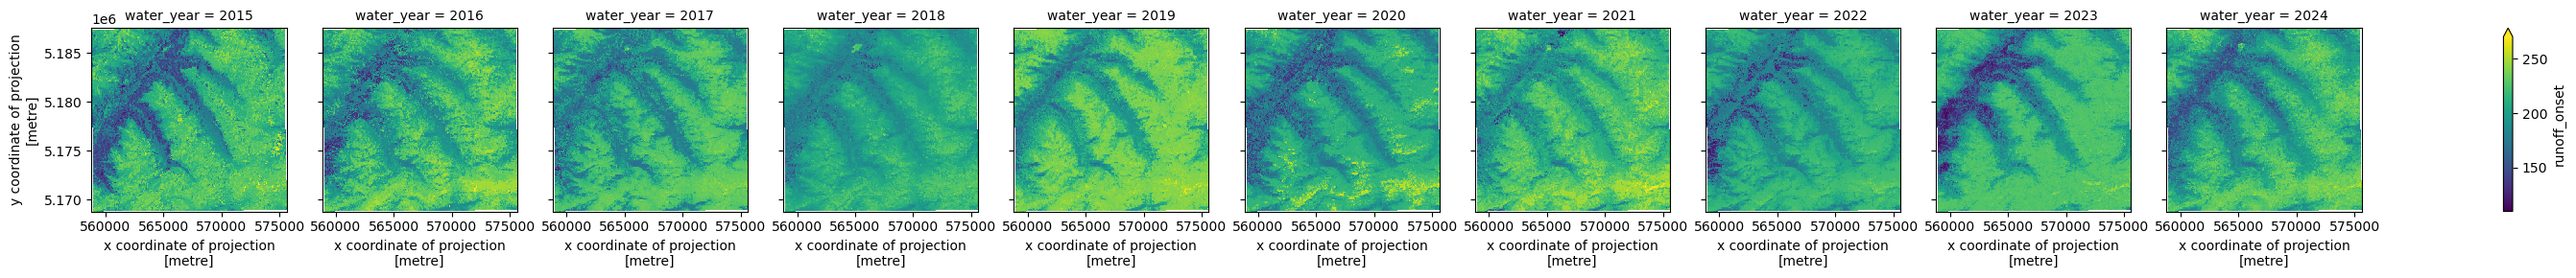

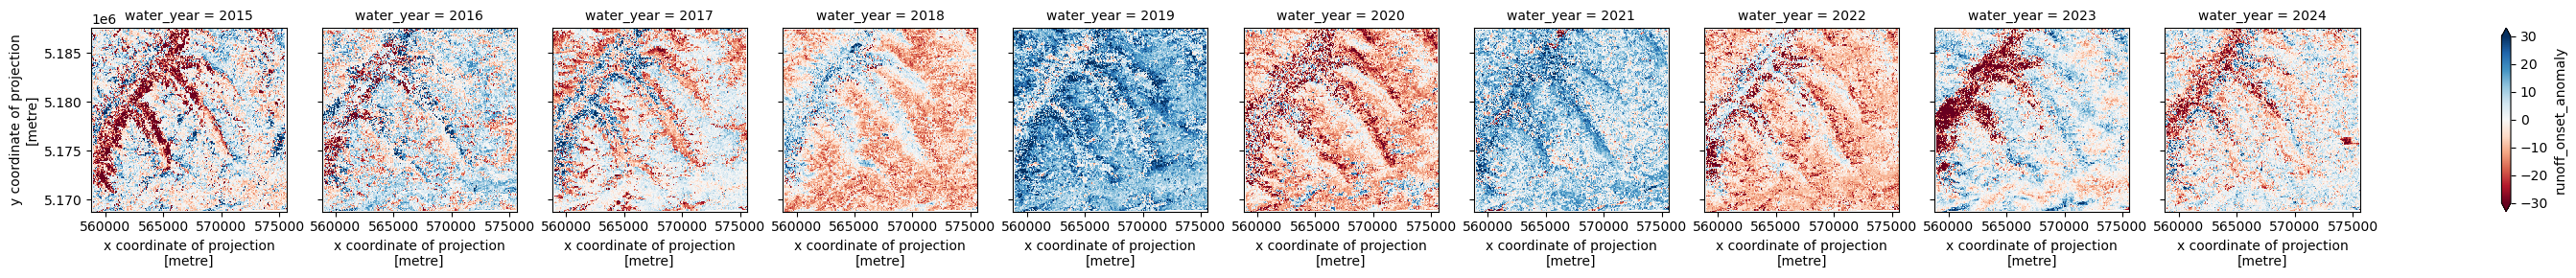

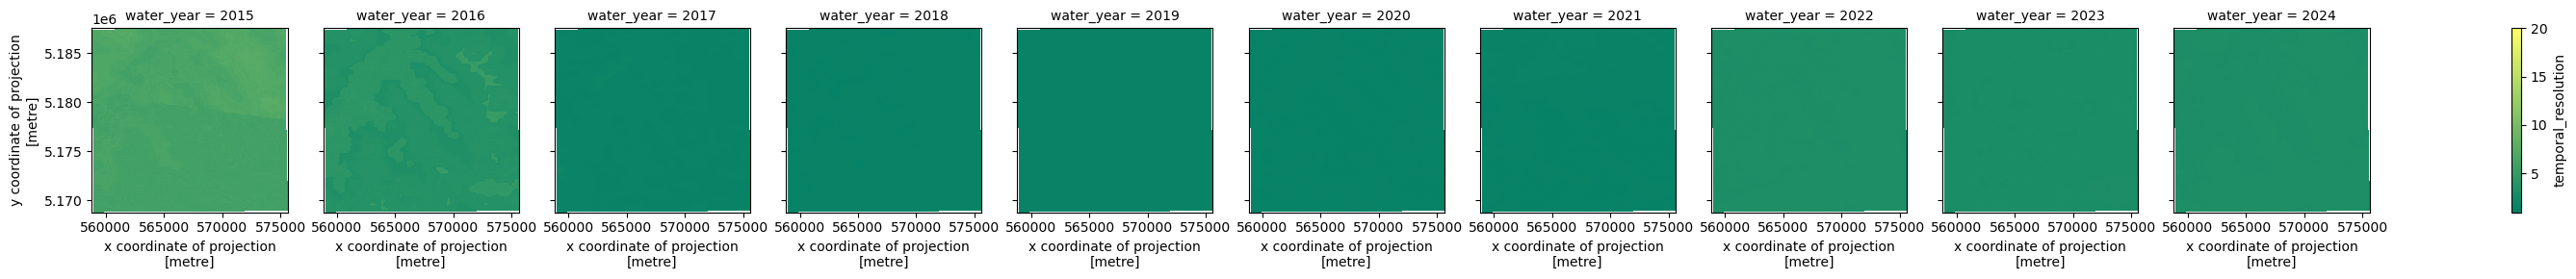

In [ ]:
dischma_basin_utm_ds = dischma_basin_ds.rio.reproject(dischma_basin_gdf.estimate_utm_crs())

f,axs = plt.subplots(figsize=(15, 5), ncols=3, nrows=1)
dischma_basin_utm_ds["runoff_onset_median"].plot.imshow(ax=axs[0], cmap='viridis', vmin=110, vmax=270, cbar_kwargs={'label': 'day of water year'})
dischma_basin_utm_ds["runoff_onset_mad"].plot.imshow(ax=axs[1], cmap='Reds', vmin=0, vmax=60, cbar_kwargs={'label': 'days'})
dischma_basin_utm_ds["temporal_resolution_median"].plot.imshow(ax=axs[2], cmap='summer', vmin=1, vmax=20, cbar_kwargs={'label': 'days'})

for ax in axs:
    ax.axis('off')
    ax.set_aspect('equal')

axs[0].set_title("10-year median snowmelt runoff onset")
axs[1].set_title("10-year median absolute deviation")
axs[2].set_title("10-year local median temporal resolution")
f.tight_layout()

dischma_basin_utm_ds['runoff_onset_anomaly'] = dischma_basin_utm_ds['runoff_onset'] - dischma_basin_utm_ds['runoff_onset_median']

dischma_basin_utm_ds["runoff_onset"].plot.imshow(col='water_year', cmap='viridis', vmin=110, vmax=270)
dischma_basin_utm_ds["runoff_onset_anomaly"].plot.imshow(col='water_year', cmap='RdBu', vmin=-30, vmax=30)
dischma_basin_utm_ds["temporal_resolution"].plot.imshow(col='water_year', cmap='summer', vmin=1, vmax=20)

In [ ]:
dischma_basin_ds.to_netcdf("geometries/bareerah_alps/dischma_basin_subset.nc")
test_ds = xr.open_dataset("geometries/bareerah_alps/dischma_basin_subset.nc",decode_coords='all')
test_ds

<xarray.Dataset> Size: 10MB
Dimensions:                     (latitude: 232, longitude: 302, water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2kB 46.84 46.84 ... 46.67
  * longitude                   (longitude) float64 2kB 9.771 9.772 ... 9.988
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
    spatial_ref                 int64 8B ...
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 3MB ...
    runoff_onset_mad            (latitude, longitude) float64 561kB ...
    runoff_onset_median         (latitude, longitude) float32 280kB ...
    temporal_resolution         (water_year, latitude, longitude) float64 6MB ...
    temporal_resolution_median  (latitude, longitude) float64 561kB ...
Attributes:
    processed_tiles:  []